# **Install Library**

In [ ]:
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    Input,
    LayerNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers

import yfinance as yf

warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

# **Configuration**

In [ ]:
class Config:

    SYMBOL = "GC=F"

    PERIOD = "10y"

    INTERVAL = "1d"

    SEQUENCE_LEN = 60

    BATCH_SIZE = 32

    EPOCHS = 150

    LEARNING_RATE = 0.0001

    DROPOUT_RATE = 0.4

    L2_REG = 1e-4

    GRAD_CLIP = 1.0

    TEST_SPLIT = 0.2

    MODEL_SAVE = "gold_bilstm.keras"

    RESULT_PLOT = "hasil_prediksi.png"

    FORECAST_DAYS = 7

    OUTPUT_DATASET = "gold_featured_dataset.csv"


cfg = Config()

# **Data Collection**

In [ ]:
print("=" * 60)
print("REALTIME GOLD PRICE PREDICTION")
print("=" * 60)

print("\n[1/10] Fetching realtime data...")

gold = yf.download(
    "GC=F",
    period=cfg.PERIOD,
    interval=cfg.INTERVAL,
    auto_adjust=True
)

# ==========================================
# USD TO IDR EXCHANGE RATE
# ==========================================

usd_idr = yf.download(
    "IDR=X",
    period=cfg.PERIOD,
    interval=cfg.INTERVAL,
    auto_adjust=True
)

# ==========================================
# FIX MULTI INDEX
# ==========================================

if isinstance(gold.columns, pd.MultiIndex):
    gold.columns = gold.columns.get_level_values(0)

if isinstance(usd_idr.columns, pd.MultiIndex):
    usd_idr.columns = usd_idr.columns.get_level_values(0)

# ==========================================
# RESET INDEX
# ==========================================

gold.reset_index(inplace=True)
usd_idr.reset_index(inplace=True)

# ==========================================
# MERGE DATASET
# ==========================================

df = pd.DataFrame()

df["Date"] = gold["Date"]

df["Gold_USD_OZ"] = gold["Close"]

df["USDIDR"] = usd_idr["Close"]

# ==========================================
# CONVERT USD/OZ TO IDR/GRAM
# ==========================================

df["Close"] = (
    df["Gold_USD_OZ"] * df["USDIDR"]
) / 31.1035

df["Open"] = (
    gold["Open"] * usd_idr["Close"]
) / 31.1035

df["High"] = (
    gold["High"] * usd_idr["Close"]
) / 31.1035

df["Low"] = (
    gold["Low"] * usd_idr["Close"]
) / 31.1035

df["Volume"] = gold["Volume"]

df.head()

REALTIME GOLD PRICE PREDICTION

[1/10] Fetching realtime data...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,Date,Gold_USD_OZ,USDIDR,Close,Open,High,Low,Volume
0,2016-05-31,1214.800049,13560.0,529608.843446,528606.105422,530829.510150,522720.594145,6432
1,2016-06-01,1211.900024,13631.0,531110.943553,532776.248153,534573.101599,528262.341305,2717
2,2016-06-02,1209.800049,13643.0,530657.387952,531797.821245,533815.519154,530569.629364,1627
3,2016-06-03,1240.099976,13610.0,542632.201126,529067.489759,544557.525680,527886.068522,1622
4,2016-06-06,1244.599976,13610.0,544601.272131,544513.779230,545782.746783,542588.454676,1135


# **Data Understanding**

In [ ]:
print("\n========== DATA INFORMATION ==========")

print(df.info())

print("\n========== FIRST 5 ROWS ==========")

display(df.head())

print("\n========== LAST 5 ROWS ==========")

display(df.tail())

print("\n========== DATA SHAPE ==========")

print(df.shape)


========== DATA INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2512 non-null   datetime64[ns]
 1   Gold_USD_OZ  2512 non-null   float64       
 2   USDIDR       2512 non-null   float64       
 3   Close        2512 non-null   float64       
 4   Open         2512 non-null   float64       
 5   High         2512 non-null   float64       
 6   Low          2512 non-null   float64       
 7   Volume       2512 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 157.1 KB
None

========== FIRST 5 ROWS ==========


,Date,Gold_USD_OZ,USDIDR,Close,Open,High,Low,Volume
0,2016-05-31,1214.800049,13560.0,529608.843446,528606.105422,530829.510150,522720.594145,6432
1,2016-06-01,1211.900024,13631.0,531110.943553,532776.248153,534573.101599,528262.341305,2717
2,2016-06-02,1209.800049,13643.0,530657.387952,531797.821245,533815.519154,530569.629364,1627
3,2016-06-03,1240.099976,13610.0,542632.201126,529067.489759,544557.525680,527886.068522,1622
4,2016-06-06,1244.599976,13610.0,544601.272131,544513.779230,545782.746783,542588.454676,1135



========== LAST 5 ROWS ==========


,Date,Gold_USD_OZ,USDIDR,Close,Open,High,Low,Volume
2507,2026-05-21,4539.799805,16876.599609,2.463272e+06,2.445584e+06,2.463272e+06,2.443739e+06,426
2508,2026-05-22,4521.000000,16939.000000,2.462142e+06,2.461325e+06,2.467206e+06,2.461107e+06,40
2509,2026-05-26,4500.399902,16960.099609,2.453976e+06,2.493454e+06,2.493454e+06,2.453976e+06,1261
2510,2026-05-27,4447.500000,16897.000000,2.416108e+06,2.411871e+06,2.416108e+06,2.411871e+06,1261
2511,2026-05-28,4536.799805,16820.000000,2.453389e+06,2.448414e+06,2.461176e+06,2.444033e+06,8584



========== DATA SHAPE ==========
(2512, 8)


# **Data Dictionary**

In [ ]:
data_dictionary = pd.DataFrame({

    "Variable": [

        "Date",
        "Gold_USD_OZ",
        "USDIDR",
        "Close",
        "Open",
        "High",
        "Low",
        "Volume"
    ],

    "Description": [

        "Tanggal data harga emas",
        "Harga emas dunia dalam USD/OZ",
        "Nilai tukar USD terhadap IDR",
        "Harga emas dalam IDR/gram",
        "Harga pembukaan emas",
        "Harga tertinggi emas",
        "Harga terendah emas",
        "Volume perdagangan emas"
    ]
})

display(data_dictionary)

,Variable,Description
0,Date,Tanggal data harga emas
1,Gold_USD_OZ,Harga emas dunia dalam USD/OZ
2,USDIDR,Nilai tukar USD terhadap IDR
3,Close,Harga emas dalam IDR/gram
4,Open,Harga pembukaan emas
5,High,Harga tertinggi emas
6,Low,Harga terendah emas
7,Volume,Volume perdagangan emas


# **Data Cleaning**

In [ ]:
print("\n========== MISSING VALUES ==========")

print(df.isnull().sum())

print("\n========== DUPLICATE DATA ==========")

print(df.duplicated().sum())

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print("\nData cleaning completed")

print("\nFinal data shape:")

print(df.shape)


========== MISSING VALUES ==========
Date           0
Gold_USD_OZ    0
USDIDR         0
Close          0
Open           0
High           0
Low            0
Volume         0
dtype: int64

========== DUPLICATE DATA ==========
0

Data cleaning completed

Final data shape:
(2512, 8)


# **Exploratory Data Analysis**

## **Bagaimana tren harga emas selama 10 tahun terakhir?**

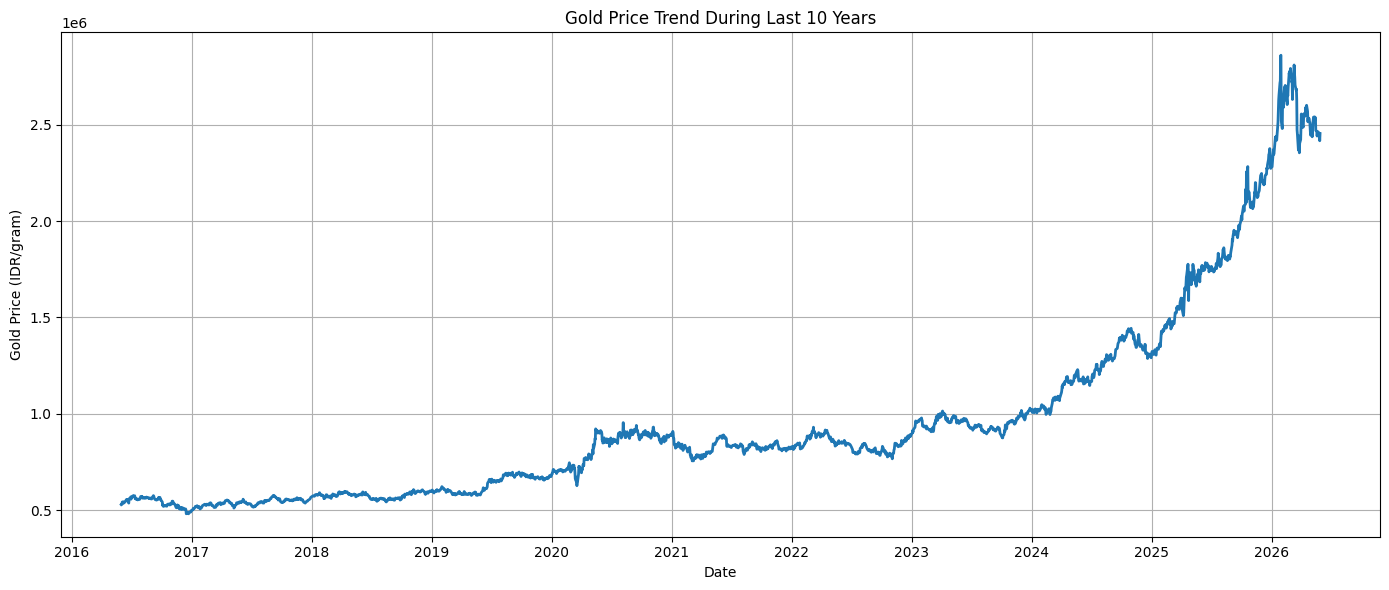

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=2
)

plt.title(
    "Gold Price Trend During Last 10 Years"
)

plt.xlabel("Date")

plt.ylabel("Gold Price (IDR/gram)")

plt.grid(True)

plt.tight_layout()

plt.show()

## **Insight**
Harga emas dalam Rupiah naik hampir 5 kali lipat dalam 10 tahun terakhir, dari sekitar Rp500.000/gram (2016) menjadi Rp2.500.000/gram (2026), dengan lonjakan terbesar terjadi di periode 2025–2026


## **Bagaimana distribusi harga emas?**

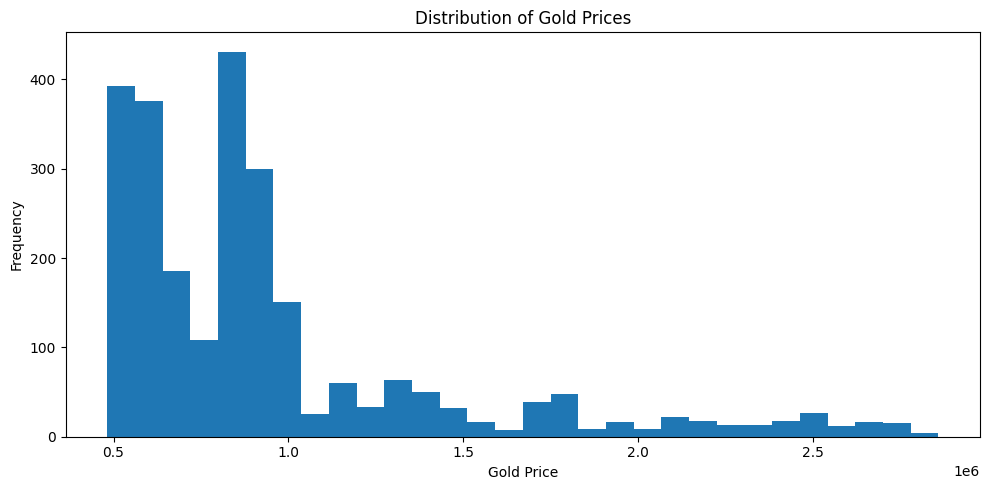

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Close"],
    bins=30
)

plt.title(
    "Distribution of Gold Prices"
)

plt.xlabel("Gold Price")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## **Insight**
Sebagian besar harga emas selama 10 tahun terakhir terkonsentrasi di kisaran Rp500.000–900.000/gram, yang berarti harga emas berada di level rendah tersebut dalam mayoritas waktu. Sementara harga di atas Rp1.000.000/gram jauh lebih jarang terjadi, yang berarti mencerminkan bahwa lonjakan harga tinggi merupakan fenomena relatif baru, khususnya yang terjadi sejak tahun 2025.

## **Bagaimana perubahan harga emas harian?**

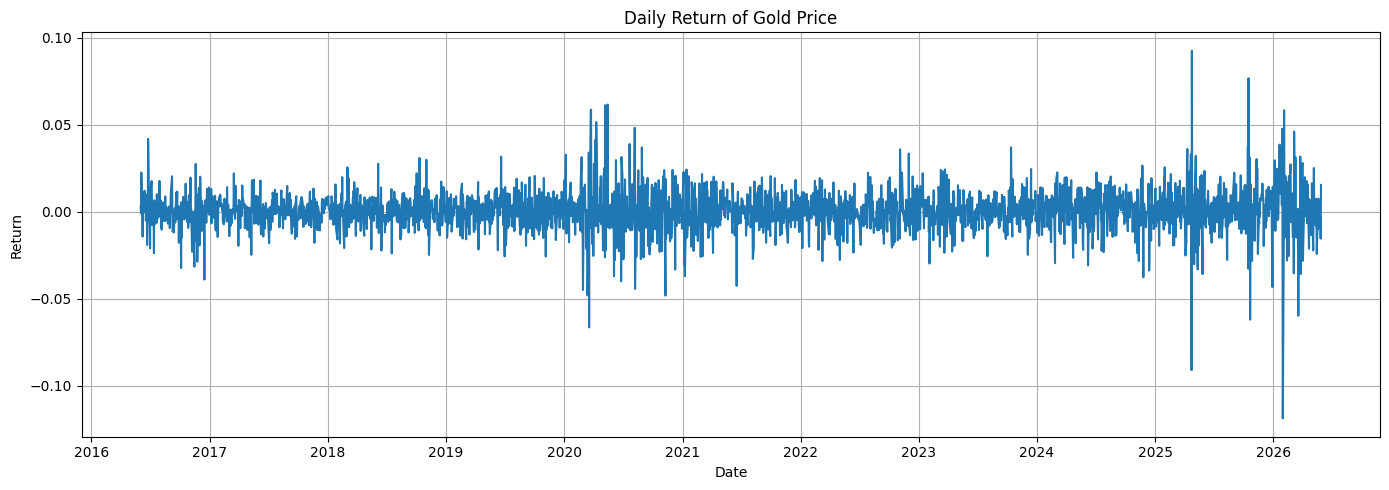

In [ ]:
df["Daily_Return"] = (
    df["Close"].pct_change()
)

plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Daily_Return"]
)

plt.title(
    "Daily Return of Gold Price"
)

plt.xlabel("Date")

plt.ylabel("Return")

plt.grid(True)

plt.tight_layout()

plt.show()

## **Insight**
Perubahan harga emas harian umumnya sangat kecil, berkisar di sekitar 0% hingga ±2% per hari. Namun terdapat dua periode dengan gejolak ekstrem, yaitu sekitar tahun 2020 (awal pandemi COVID-19) dan tahun 2025–2026, di mana harga bisa berubah hingga ±6–12% dalam sehari. Artinya, emas relatif stabil di hari-hari normal, tetapi bisa sangat fluktuatif saat terjadi krisis.

## **Bagaimana tren jangka pendek dan panjang harga emas?**

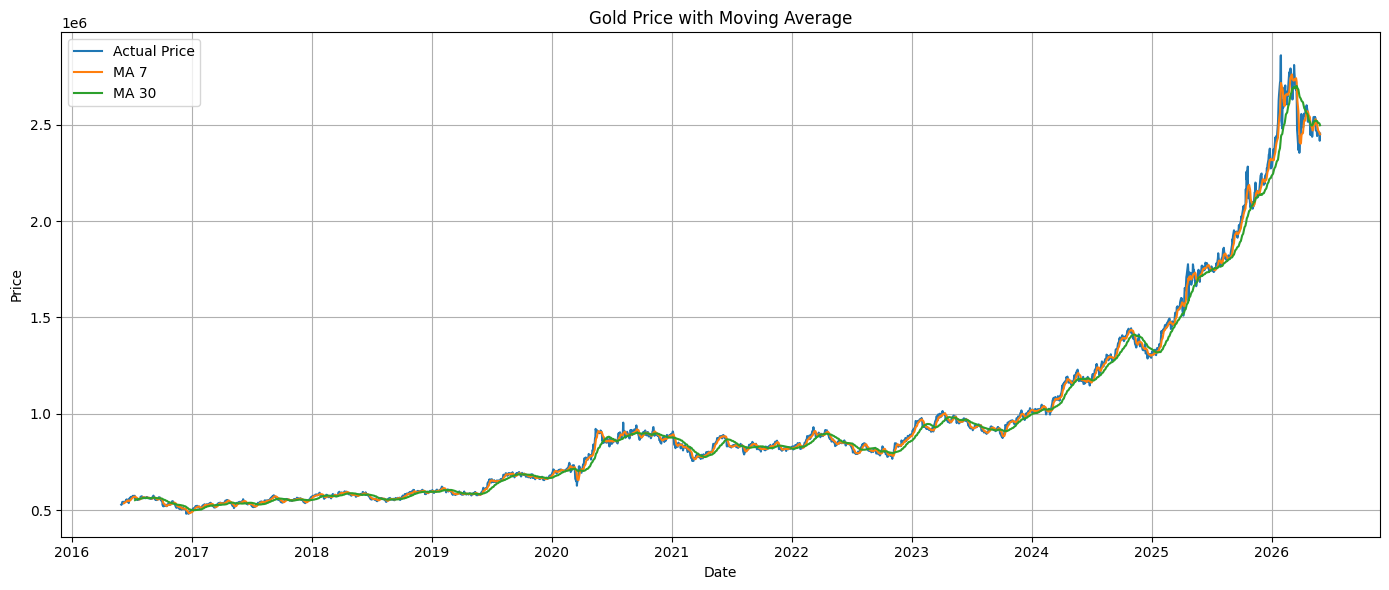

In [ ]:
df["MA7"] = (
    df["Close"]
    .rolling(window=7)
    .mean()
)

df["MA30"] = (
    df["Close"]
    .rolling(window=30)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Close"],
    label="Actual Price"
)

plt.plot(
    df["Date"],
    df["MA7"],
    label="MA 7"
)

plt.plot(
    df["Date"],
    df["MA30"],
    label="MA 30"
)

plt.title(
    "Gold Price with Moving Average"
)

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

## **Insight**
MA 7 (jangka pendek) dan MA 30 (jangka panjang) bergerak sangat berdekatan sepanjang 10 tahun, menandakan tren kenaikan emas bersifat konsisten dan berkelanjutan, bukan sekadar lonjakan sesaat. Artinya, baik investor jangka pendek maupun panjang sama-sama melihat sinyal tren naik yang kuat, dengan akselerasi paling tajam terjadi sejak tahun 2025.

## **Seberapa tinggi volatilitas harga emas?**

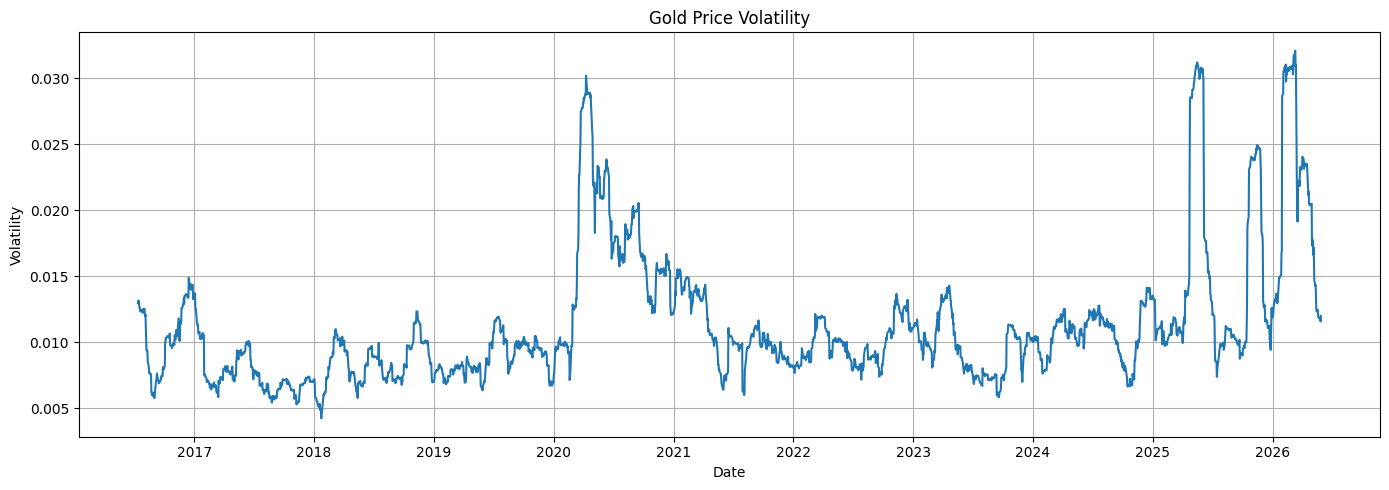

In [ ]:
df["Volatility"] = (
    df["Daily_Return"]
    .rolling(30)
    .std()
)

plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Volatility"]
)

plt.title(
    "Gold Price Volatility"
)

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.tight_layout()

plt.show()

## **Insight**
Harga emas umumnya bergerak stabil dan tenang di sebagian besar waktu, namun terdapat dua momen di mana harganya menjadi sangat tidak menentu, yaitu saat pandemi COVID-19 (2020) dan tahun 2025–2026. Di luar dua periode tersebut, emas terbilang aman dan tidak bergejolak sehingga menjadikannya pilihan investasi yang relatif nyaman untuk jangka panjang.

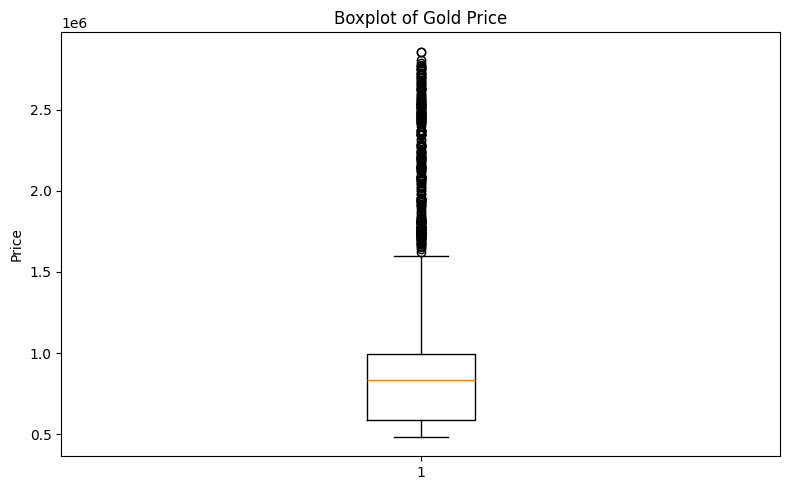

In [ ]:
# =========================================================
# SECTION 12 - BOXPLOT ANALYSIS
# =========================================================
# BUSINESS QUESTION:
# Apakah terdapat outlier pada data harga emas?
# =========================================================

plt.figure(figsize=(8,5))

plt.boxplot(
    df["Close"].dropna()
)

plt.title(
    "Boxplot of Gold Price"
)

plt.ylabel("Price")

plt.tight_layout()

plt.show()

## **Insight**
Terdapat banyak outlier pada data harga emas. Harga emas umumnya berada di kisaran Rp600.000–1.000.000/gram, namun terdapat banyak titik harga yang jauh melampaui batas tersebut, bahkan hingga Rp2.800.000/gram. Outlier ini bukan anomali data, melainkan mencerminkan lonjakan harga nyata yang terjadi sejak tahun 2025, di mana harga emas memasuki level yang belum pernah terjadi sebelumnya dalam 10 tahun terakhir.

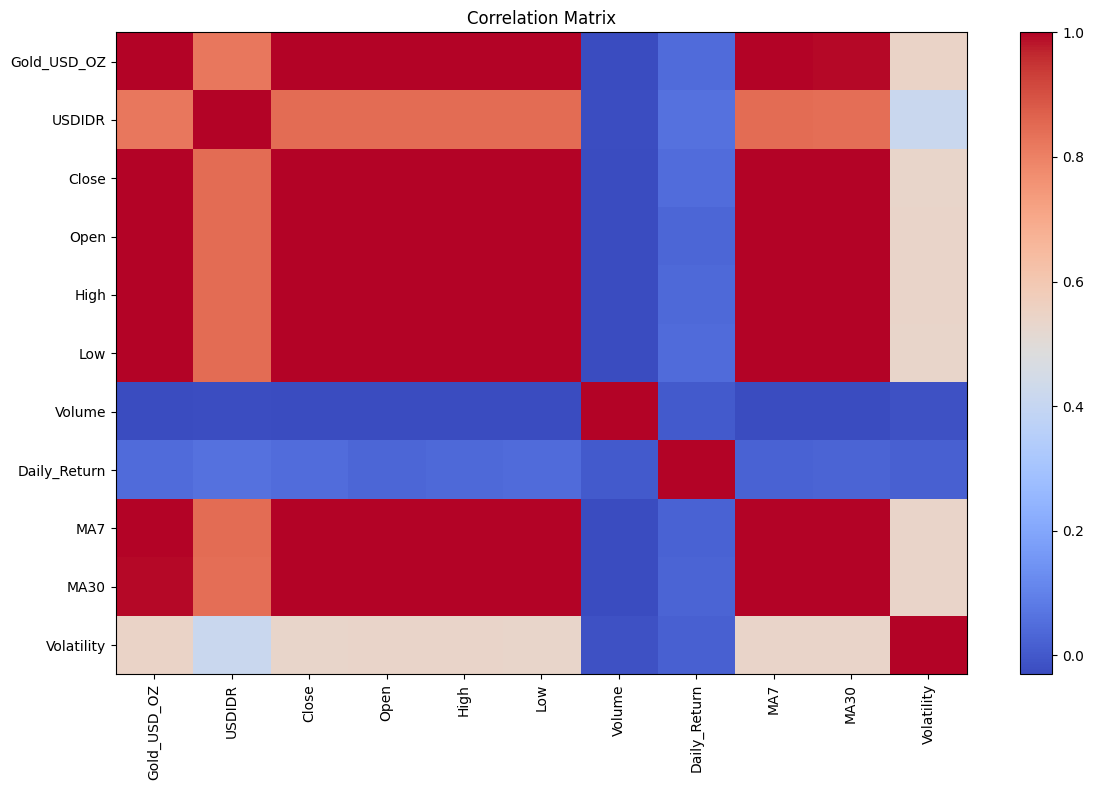

In [ ]:
# =========================================================
# SECTION 13 - CORRELATION ANALYSIS
# =========================================================
# BUSINESS QUESTION:
# Bagaimana hubungan antar variabel?
# =========================================================

numeric_df = df.select_dtypes(
    include=[np.number]
)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

plt.imshow(
    corr,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Correlation Matrix"
)

plt.tight_layout()

plt.show()

## **Insight**
Terdapat tiga pola hubungan utama antar variabel:
1.   Harga emas & kurs USD/IDR bergerak searah, ketika Dollar menguat (Rupiah melemah), harga emas dalam Rupiah ikut naik.
2.   Volume transaksi tidak berkaitan dengan harga banyak atau sedikitnya orang yang bertransaksi emas tidak memengaruhi naik turunnya harga.
3. Volatilitas berdiri sendiri, gejolak harga harian tidak berkorelasi kuat dengan variabel lain, artinya ketidakstabilan harga sulit diprediksi hanya dari faktor-faktor yang tersedia.




# **Feature Engineering**

In [ ]:
def add_features(df):

    print("\nFeature engineering...")

    c = pd.to_numeric(
        df["Close"],
        errors="coerce"
    ).astype(np.float32)

    df["ret1d"] = c.pct_change(1)

    df["ret3d"] = c.pct_change(3)

    df["ret5d"] = c.pct_change(5)

    df["ret10d"] = c.pct_change(10)

    df["ret21d"] = c.pct_change(21)

    df["MA7_r"] = c.rolling(7).mean() / c

    df["MA21_r"] = c.rolling(21).mean() / c

    df["MA50_r"] = c.rolling(50).mean() / c

    df["vol7"] = c.rolling(7).std() / c

    df["vol21"] = c.rolling(21).std() / c

    delta = c.diff()

    gain = delta.clip(lower=0).rolling(14).mean()

    loss = (
        -delta.clip(upper=0)
    ).rolling(14).mean()

    df["RSI"] = (
        100 - (
            100 / (
                1 + gain / (loss + 1e-9)
            )
        )
    ) / 100

    ema12 = c.ewm(
        span=12,
        adjust=False
    ).mean()

    ema26 = c.ewm(
        span=26,
        adjust=False
    ).mean()

    df["MACD_r"] = (
        ema12 - ema26
    ) / c

    bb_mid = c.rolling(20).mean()

    bb_std = c.rolling(20).std()

    df["BB_pos"] = (
        c - bb_mid
    ) / (2 * bb_std + 1e-9)

    dates = pd.to_datetime(df["Date"])

    df["DayOfWeek"] = np.sin(
        2 * np.pi *
        dates.dt.dayofweek / 5
    )

    df["Month_sin"] = np.sin(
        2 * np.pi *
        (dates.dt.month - 1) / 12
    )

    df["Month_cos"] = np.cos(
        2 * np.pi *
        (dates.dt.month - 1) / 12
    )

    df["HL_ratio"] = (
        (df["High"] - df["Low"]) / c
    )

    df["OC_ratio"] = (
        (c - df["Open"]) / c
    )

    # TARGET

    df["target"] = np.log(
        c.shift(-1) / c
    )

    df.dropna(inplace=True)

    feature_cols = [

        "ret1d",
        "ret3d",
        "ret5d",
        "ret10d",
        "ret21d",

        "MA7_r",
        "MA21_r",
        "MA50_r",

        "vol7",
        "vol21",

        "RSI",

        "MACD_r",

        "BB_pos",

        "DayOfWeek",

        "Month_sin",
        "Month_cos",

        "HL_ratio",
        "OC_ratio"
    ]

    return df, feature_cols

In [ ]:
# Apply feature engineering to the DataFrame
df, feature_cols = add_features(df)

# Save the featured DataFrame to CSV
df.to_csv(
    cfg.OUTPUT_DATASET,
    index=False
)

print("\nDataset exported successfully!")

print("\nOutput File:")
print(cfg.OUTPUT_DATASET)

print("\nFinal Shape:")
print(df.shape)

print("\nFeature Columns:")

for f in feature_cols:
    print("- ", f)

print("\nTarget Column:")
print("- target")


Feature engineering...

Dataset exported successfully!

Output File:
gold_featured_dataset.csv

Final Shape:
(2462, 31)

Feature Columns:
-  ret1d
-  ret3d
-  ret5d
-  ret10d
-  ret21d
-  MA7_r
-  MA21_r
-  MA50_r
-  vol7
-  vol21
-  RSI
-  MACD_r
-  BB_pos
-  DayOfWeek
-  Month_sin
-  Month_cos
-  HL_ratio
-  OC_ratio

Target Column:
- target


In [ ]:
import pandas as pd

df_loaded = pd.read_csv("gold_featured_dataset.csv")
display(df_loaded.head())

,Date,Gold_USD_OZ,USDIDR,Close,Open,High,Low,Volume,Daily_Return,MA7,...,vol21,RSI,MACD_r,BB_pos,DayOfWeek,Month_sin,Month_cos,HL_ratio,OC_ratio,target
0,2016-08-09,1339.000000,13103.0,564081.759288,561048.629247,564250.277940,559658.414648,620,0.001372,566832.514468,...,0.009618,0.619493,0.004213,0.188354,0.951057,-0.5,-0.866025,0.008140,0.005377,0.005399
1,2016-08-10,1344.300049,13122.0,567135.699864,567346.640755,571312.288304,567135.699864,110,0.005414,566553.573518,...,0.009769,0.595496,0.004263,0.450719,0.587785,-0.5,-0.866025,0.007364,-0.000372,-0.002636
2,2016-08-11,1342.500000,13105.0,565642.532191,565263.320207,568971.090712,562398.271574,666,-0.002633,565529.926575,...,0.009797,0.610328,0.004072,0.297092,-0.587785,-0.5,-0.866025,0.011620,0.000670,-0.005309
3,2016-08-12,1335.800049,13101.0,562647.819046,563069.025663,569387.124912,561552.640709,113,-0.005294,564812.941383,...,0.009846,0.582162,0.003463,0.011735,-0.951057,-0.5,-0.866025,0.013924,-0.000749,0.001988
4,2016-08-15,1340.300049,13083.0,563767.599750,562169.193178,563893.757313,560949.361988,62,0.001990,564156.868702,...,0.009655,0.584930,0.003082,0.079833,0.000000,-0.5,-0.866025,0.005223,0.002835,0.008727


In [ ]:
from google.colab import files
files.download('gold_featured_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
date_price_df = df[['Date', 'Close']]
display(date_price_df.head())

,Date,Close
49,2016-08-09,564081.759288
50,2016-08-10,567135.699864
51,2016-08-11,565642.532191
52,2016-08-12,562647.819046
53,2016-08-15,563767.599750


In [ ]:
from google.colab import files

# Memilih kolom yang diminta termasuk Volume
# Catatan: Kolom harga (Open, High, Low, Close) sudah dalam satuan Rupiah (IDR/gram)
selected_columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Daily_Return', 'Volume']
df_custom_with_vol = df[selected_columns].copy()

# Menampilkan 5 data teratas untuk verifikasi
display(df_custom_with_vol.head())

# Menyimpan ke file CSV baru
file_name_vol = 'data_emas_lengkap_kustom.csv'
df_custom_with_vol.to_csv(file_name_vol, index=False)

# Mengunduh file
files.download(file_name_vol)

print(f"Konfirmasi: Data dalam '{file_name_vol}' menggunakan satuan Rupiah (IDR).")
print(f"File berhasil diproses dan siap diunduh.")

,Date,Open,High,Low,Close,Daily_Return,Volume
49,2016-08-09,561048.629247,564250.277940,559658.414648,564081.759288,0.001372,620
50,2016-08-10,567346.640755,571312.288304,567135.699864,567135.699864,0.005414,110
51,2016-08-11,565263.320207,568971.090712,562398.271574,565642.532191,-0.002633,666
52,2016-08-12,563069.025663,569387.124912,561552.640709,562647.819046,-0.005294,113
53,2016-08-15,562169.193178,563893.757313,560949.361988,563767.599750,0.001990,62


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Konfirmasi: Data dalam 'data_emas_lengkap_kustom.csv' menggunakan satuan Rupiah (IDR).
File berhasil diproses dan siap diunduh.
